**Author:** Tianqi Shen & GPT-4o

**Date:** 25 May 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## 2D Spectral Slice Case

To examine when Muon performs well, we consider a toy model with a two-dimensional anisotropic spectral landscape. The construction proceeds as follows (the key idea is to restrict the matrix parameter to two orthogonal spectral directions):
* Choose orthogonal rank-1 directions:
$$
U = uu^\top, \qquad V = vv^\top, \qquad \langle U,V \rangle_F = 0.
$$
* Parameterize the matrix using two scalar coordinates:
$$
X(a,b) = aU + bV.
$$
* Define an anisotropic quadratic objective with $\lambda_s \gg \lambda_w$:
$$
h(a,b) = \frac12 \lambda_w (a - a^\star)^2 + \frac12 \lambda_s (b - b^\star)^2.
$$
* Lift the gradient back to matrix space:
$$
\nabla_X h = \lambda_w (a - a^\star) U + \lambda_s (b - b^\star) V.
$$

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import argparse
import numpy as np
from typing import List, Tuple
from itertools import chain
from tqdm import tqdm

### Functional Helpers for Matrix Computation
- Construct two orthonormal rank-1 matrix directions $U$ and $V$ (*func:* `make_spectral_basis`):
$$
U = \left( \frac{u}{\|u\|_2} \right) \left( \frac{u}{\|u\|_2} \right)^\top,
\qquad
V = \left( \frac{v}{\|v\|_2} \right) \left( \frac{v}{\|v\|_2} \right)^\top,
\qquad
\langle U,V \rangle_F = 0.
$$
- Compute the Frobenius inner product of matrices $M$ and $N$ (*func:* `fro_inner`):
$$
\langle M,N \rangle_F.
$$
- Project a matrix $X$ onto spectral coordinates $(a,b)$ (*func:* `coords_from_matrix`):
$$
a = \langle X,U \rangle_F, \qquad b = \langle X,V \rangle_F.
$$
- Lift spectral coordinates $(a,b)$ to a matrix $X$ (*func:* `matrix_from_coords`):
$$
X = a U + b V.
$$
- Evaluate the loss $h$ (*func:* `loss_value`):
$$
h(a,b) = \frac12 \lambda_w (a - a^\star)^2 + \frac12 \lambda_s (b - b^\star)^2.
$$
- Compute the gradient in matrix space (*func:* `grad_matrix`):
$$
\nabla_X h = \lambda_w (a - a^\star) U + \lambda_s (b - b^\star) V.
$$
- Compute the polar factor (matrix sign) for this toy setting (*func:* `toy_msign`):
$$
\mathtt{msign}(aU + bV) = \mathtt{sign}(a) U + \mathtt{sign}(b) V.
$$

In [2]:
def make_spectral_basis(u=(1.0, 1.0), v=(1.0, -1.0), normalize=True, ortho_tol=1e-10,):
    u = np.asarray(u, dtype=float).reshape(2,)
    v = np.asarray(v, dtype=float).reshape(2,)

    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)
    if u_norm <= 0 or v_norm <= 0:
        raise ValueError(f"u and v must be nonzero. Got ||u||={u_norm}, ||v||={v_norm}")

    if normalize:
        normed_u = u / u_norm
        normed_v = v / v_norm
        dot = float(np.dot(normed_u, normed_v))
        if abs(dot) > ortho_tol:
            raise ValueError(
                f"u and v are not orthogonal after normalization: "
                f"dot(u/||u||, v/||v||)={dot} (tol={ortho_tol})"
            )
        u_use, v_use = normed_u, normed_v
    else:
        dot = float(np.dot(u, v))
        if abs(dot) > ortho_tol:
            raise ValueError(
                f"u and v are not orthogonal: dot(u,v)={dot} (tol={ortho_tol})"
            )
        u_use, v_use = u, v

    U = np.outer(u_use, u_use)
    V = np.outer(v_use, v_use)
    return U, V

def fro_inner(M, N):
    return float(np.sum(M * N))

def coords_from_matrix(X, U, V):
    return np.array([fro_inner(X, U), fro_inner(X, V)])

def matrix_from_coords(a, b, U, V):
    return a * U + b * V

def loss_value(a, b, lam_weak, lam_strong, target_a, target_b):
    return 0.5 * lam_weak * (a - target_a) ** 2 + 0.5 * lam_strong * (b - target_b) ** 2

def grad_matrix(X, U, V, lam_weak, lam_strong, target_a, target_b):
    a, b = coords_from_matrix(X, U, V)
    return lam_weak * (a - target_a) * U + lam_strong * (b - target_b) * V

def toy_msign(Y, U, V, eps=1e-12):
    alpha = fro_inner(Y, U)
    beta = fro_inner(Y, V)

    s_alpha = 0.0 if abs(alpha) < eps else np.sign(alpha)
    s_beta = 0.0 if abs(beta) < eps else np.sign(beta)

    return s_alpha * U + s_beta * V

### Functional Helpers for Optimization (“pure” setting)
- Simulate Muon and baseline optimizers (momentum-GD or Adam) using a single optimizer throughout (*func:* `simulate_pure`). Define the gradient at iteration $t$ as $G_t := \nabla_X h \left( a_{t-1},b_{t-1} \right)$
 - Gradient descent with momentum (momentum-GD):
   $$
   M_t \gets G_t + \xi M_{t-1}, \qquad X_{t+1} \gets X_t - \eta^{\rm GD}\, M_t.
   $$
 - Adam (all operations are element-wise):
   $$
   M_t \gets \beta_1 M_{t-1} + (1 - \beta_1) G_t,
   \\
   V_t \gets \beta_2 V_{t-1} + (1 - \beta_2) \left(G_t \odot G_t\right),
   \\
   \hat{M}_t \gets \frac{M_t}{1 - \beta_1^t}, 
   \qquad 
   \hat{V}_t \gets \frac{V_t}{1 - \beta_2^t},
   \qquad
   X_{t+1} \gets X_t - \eta^{\rm Adam}\, \frac{\hat{M}_t}{\sqrt{\hat{V}_t} + \epsilon}.
   $$
 - Muon:
   $$
   M_t \gets G_t + \xi M_{t-1}, \qquad X_{t+1} \gets X_t - \eta^{\rm Muon}\, \mathtt{msign}(M_t).
   $$

In [3]:
def simulate_pure(
    u, 
    v,
    steps,
    lam_weak,
    lam_strong,
    start_a,
    start_b,
    target_a,
    target_b,
    lr_m_gd,
    lr_adam,
    lr_muon,
    m_gd_momentum_xi,  # if =0, it is simplified GD (without momentum)
    muon_momentum_xi,  # if =0, it is vanilla GD (without momentum)
    adam_beta1,
    adam_beta2,
    adam_eps,
):
    U, V = make_spectral_basis(u, v)

    X_m_gd = matrix_from_coords(start_a, start_b, U, V)
    X_adam = matrix_from_coords(start_a, start_b, U, V)
    X_muon = matrix_from_coords(start_a, start_b, U, V)

    m_gd_M = np.zeros_like(X_m_gd)  # velocity / momentum buffer
    adam_M = np.zeros_like(X_adam)
    adam_V = np.zeros_like(X_adam)
    muon_M = np.zeros_like(X_muon)

    m_gd_path = []
    adam_path = []
    muon_path = []

    target = np.array([target_a, target_b])

    for t in range(1, steps + 1):
        m_gd_path.append(coords_from_matrix(X_m_gd, U, V))
        adam_path.append(coords_from_matrix(X_adam, U, V))
        muon_path.append(coords_from_matrix(X_muon, U, V))

        # -------- Momentum-GD update (heavy-ball) --------
        G_gd = grad_matrix(X_m_gd, U, V, lam_weak, lam_strong, target_a, target_b)
        m_gd_M = m_gd_momentum_xi * m_gd_M + G_gd
        X_m_gd = X_m_gd - lr_m_gd * m_gd_M
        
        # -------- Adam update --------
        G_adam = grad_matrix(X_adam, U, V, lam_weak, lam_strong, target_a, target_b)
        adam_M = adam_beta1 * adam_M + (1.0 - adam_beta1) * G_adam
        adam_V = adam_beta2 * adam_V + (1.0 - adam_beta2) * (G_adam * G_adam)

        M_hat = adam_M / (1.0 - adam_beta1 ** t)
        V_hat = adam_V / (1.0 - adam_beta2 ** t)

        adam_update = M_hat / (np.sqrt(V_hat) + adam_eps)
        X_adam = X_adam - lr_adam * adam_update
        
        # -------- Muon update --------
        G_muon = grad_matrix(X_muon, U, V, lam_weak, lam_strong, target_a, target_b)

        muon_M = muon_momentum_xi * muon_M + G_muon
        muon_update = toy_msign(muon_M, U, V)
        X_muon = X_muon - lr_muon * muon_update

    m_gd_path.append(coords_from_matrix(X_m_gd, U, V))
    adam_path.append(coords_from_matrix(X_adam, U, V))
    muon_path.append(coords_from_matrix(X_muon, U, V))

    return np.array(m_gd_path), np.array(adam_path), np.array(muon_path)

### Functional Helpers for Optimization (“hybrid” setting)
- Muon + momentum-GD
- Muon + Adam

In [4]:
def _rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x * x)))

def simulate_hybrid(
    u,
    v,
    steps,
    lam_weak,
    lam_strong,
    start_a,
    start_b,
    target_a,
    target_b,
    # ---- switch times (inclusive convention described below) ----
    switch_muon_to_m_gd,  # int: after this step, use momentum-GD
    switch_muon_to_adam,  # int: after this step, use Adam
    # ---- learning rates ----
    lr_muon,
    lr_m_gd,
    lr_adam,
    # ---- momentums / adam params ----
    muon_momentum_xi,
    m_gd_momentum_xi,
    adam_beta1,
    adam_beta2,
    adam_eps,
    # ---- momentum inheritance ----
    inherit_scale=None,   # float or None; applies when muon_momentum_xi != 0
):
    """
    Returns:
      path_muon_to_mgd:  (steps+1, 2)
      path_muon_to_adam: (steps+1, 2)

    Switching convention:
      - For t = 1..steps:
          - if t <= switch: run Muon update
          - else: run the second-stage optimizer update
      Paths store coordinates BEFORE each update (like your simulate_pure), and one final point appended.
    """
    U, V = make_spectral_basis(u, v)

    # Separate state for two hybrids (so they are independent comparisons)
    X_m_gd = matrix_from_coords(start_a, start_b, U, V)
    X_adam = matrix_from_coords(start_a, start_b, U, V)

    # Muon momentum buffers (separate, because they run different switch times)
    muonM_for_m_gd = np.zeros_like(X_m_gd)
    muonM_for_adam = np.zeros_like(X_adam)

    # Second-stage states
    m_gd_M = np.zeros_like(X_m_gd)  # heavy-ball momentum buffer
    adam_M = np.zeros_like(X_adam)  # first moment
    adam_V = np.zeros_like(X_adam)  # second moment

    path_muon_to_m_gd = []
    path_muon_to_adam = []

    # Helper: decide scale for momentum inheritance
    def compute_scale(muon_M: np.ndarray) -> float:
        if inherit_scale is not None:
            return float(inherit_scale)
        # default: 1 / RMS(muon_M)
        return 1 / _rms(muon_M)

    # Run
    for t in range(1, steps + 1):
        # record positions before update
        path_muon_to_m_gd.append(coords_from_matrix(X_m_gd, U, V))
        path_muon_to_adam.append(coords_from_matrix(X_adam, U, V))

        # --------------------------
        # Hybrid 1: Muon -> Momentum-GD
        # --------------------------
        if t <= switch_muon_to_m_gd:
            G = grad_matrix(X_m_gd, U, V, lam_weak, lam_strong, target_a, target_b)
            muonM_for_m_gd = muon_momentum_xi * muonM_for_m_gd + G
            muon_update = toy_msign(muonM_for_m_gd, U, V)
            X_m_gd = X_m_gd - lr_muon * muon_update

            # If we are switching right after this update, initialize mgd_M
            if t == switch_muon_to_m_gd:
                if muon_momentum_xi == 0.0:
                    m_gd_M = np.zeros_like(m_gd_M)
                else:
                    print("RMS of muonM_for_m_gd: ", _rms(muonM_for_m_gd))
                    s = compute_scale(muonM_for_m_gd)
                    m_gd_M = s * muonM_for_m_gd
        else:
            # second stage: momentum-GD heavy-ball
            G = grad_matrix(X_m_gd, U, V, lam_weak, lam_strong, target_a, target_b)
            m_gd_M = m_gd_momentum_xi * m_gd_M + G
            X_m_gd = X_m_gd - lr_m_gd * m_gd_M

        # --------------------------
        # Hybrid 2: Muon -> Adam
        # --------------------------
        if t <= switch_muon_to_adam:
            G = grad_matrix(X_adam, U, V, lam_weak, lam_strong, target_a, target_b)
            muonM_for_adam = muon_momentum_xi * muonM_for_adam + G
            muon_update = toy_msign(muonM_for_adam, U, V)
            X_adam = X_adam - lr_muon * muon_update

            # If we are switching right after this update, initialize adam_M
            if t == switch_muon_to_adam:
                if muon_momentum_xi == 0.0:
                    adam_M = np.zeros_like(adam_M)
                    adam_V = np.zeros_like(adam_V)
                else:
                    print("RMS of muonM_for_adam: ", _rms(muonM_for_adam))
                    s = compute_scale(muonM_for_adam)
                    adam_M = s * muonM_for_adam
                    adam_V = adam_M * adam_M
#                     adam_V = G * G  # another design
        else:
            # second stage: Adam
            G = grad_matrix(X_adam, U, V, lam_weak, lam_strong, target_a, target_b)

            # Standard Adam recursion
            adam_M = adam_beta1 * adam_M + (1.0 - adam_beta1) * G
            adam_V = adam_beta2 * adam_V + (1.0 - adam_beta2) * (G * G)

            # Bias correction: use "effective Adam step index" k, starting at 1 on first Adam step.
            k = t - switch_muon_to_adam
            M_hat = adam_M / (1.0 - adam_beta1 ** k)
            V_hat = adam_V / (1.0 - adam_beta2 ** k)

            adam_update = M_hat / (np.sqrt(V_hat) + adam_eps)
            X_adam = X_adam - lr_adam * adam_update

    # final points
    path_muon_to_m_gd.append(coords_from_matrix(X_m_gd, U, V))
    path_muon_to_adam.append(coords_from_matrix(X_adam, U, V))

    return np.array(path_muon_to_m_gd), np.array(path_muon_to_adam)

### Load Hyper-parameters

In [5]:
# Load hyper-parameters
class Args:
    steps = 70
    lambda_weak = 0.6
    lambda_strong = 10
    start_a = 0.6
    start_b = 0.6
    target_a = 0.0
    target_b = 0.0
    lr_m_gd = 0.037
    lr_adam = 0.037
    lr_muon = 0.037
    muon_momentum_xi = 0.5
    m_gd_momentum_xi = 0.5  # we recommend that readers also try 0.95 and see the results
    adam_beta1 = 0.9
    adam_beta2 = 0.999
    adam_eps = 1e-8
    u = (1.0, 1.0)
    v = (1.0, -1.0)
    switch_muon_to_m_gd = 13  # int: after this step, use momentum-GD
    switch_muon_to_adam = 13  # int: after this step, use Adam
    inherit_scale = 0.0
args = Args()
    
stability_limit = 2.0 / args.lambda_strong
if args.lr_m_gd >= stability_limit and args.m_gd_momentum_xi == 0.0:
    print(
        f"Warning: GD lr_gd={args.lr_m_gd:g} is >= "
        f"2/lambda_strong={stability_limit:g}; GD may diverge or oscillate.",)
    
def add_path_arrows(ax, path, every=6, step=2, **arrow_kws):
    """
    Add small arrows along a trajectory.
    step: arrow uses segment i -> i+step
    """
    n = len(path)
    if n < step + 1:
        return
    for i in range(0, n - step, every):
        x0, y0 = path[i]
        x1, y1 = path[i + step]
        dx, dy = x1 - x0, y1 - y0
        if dx * dx + dy * dy < 1e-12:
            continue
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="->", lw=1.0, shrinkA=0, shrinkB=0, **arrow_kws
            ),
        )

def path_loss(path, lam_weak, lam_strong, ta, tb):
    a = path[:, 0]
    b = path[:, 1]
    return loss_value(a, b, lam_weak, lam_strong, ta, tb)

### Run Optimization (“pure” setting)

In [6]:
m_gd_path, adam_path, muon_path = simulate_pure(
    u=args.u,
    v=args.v,
    steps=args.steps,
    lam_weak=args.lambda_weak,
    lam_strong=args.lambda_strong,
    start_a=args.start_a,
    start_b=args.start_b,
    target_a=args.target_a,
    target_b=args.target_b,
    lr_m_gd=args.lr_m_gd,
    lr_adam=args.lr_adam,
    lr_muon=args.lr_muon,
    m_gd_momentum_xi=args.m_gd_momentum_xi,
    muon_momentum_xi=args.muon_momentum_xi,
    adam_beta1=args.adam_beta1,
    adam_beta2=args.adam_beta2,
    adam_eps=args.adam_eps,
)

loss_m_gd = path_loss(m_gd_path, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b)
loss_adam = path_loss(adam_path, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b)
loss_muon = path_loss(muon_path, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b)

iters_m_gd = np.arange(len(loss_m_gd))
iters_adam = np.arange(len(loss_adam))
iters_muon = np.arange(len(loss_muon))

print(f"final_a of momentum-GD: ", m_gd_path[-1][0])
print(f"final_b of momentum-GD: ", m_gd_path[-1][1])
print(f"final_loss of momentum-GD: ", loss_m_gd[-1])
print(f"final_a of Adam: ", adam_path[-1][0])
print(f"final_b of Adam: ", adam_path[-1][1])
print(f"final_loss of Adam: ", loss_adam[-1])
print(f"final_a of Muon: ", muon_path[-1][0])
print(f"final_b of Muon: ", muon_path[-1][1])
print(f"final_loss of Muon: ", loss_muon[-1])

final_a of momentum-GD:  0.02232411180202054
final_b of momentum-GD:  9.18438762542717e-12
final_loss of momentum-GD:  0.00014950979032473383
final_a of Adam:  0.10242123207063075
final_b of Adam:  0.006966920842724329
final_loss of Adam:  0.0033897225638037333
final_a of Muon:  0.008000000000000061
final_b of Muon:  0.008000000000000061
final_loss of Muon:  0.00033920000000000515


### Plot Results (“pure” setting)

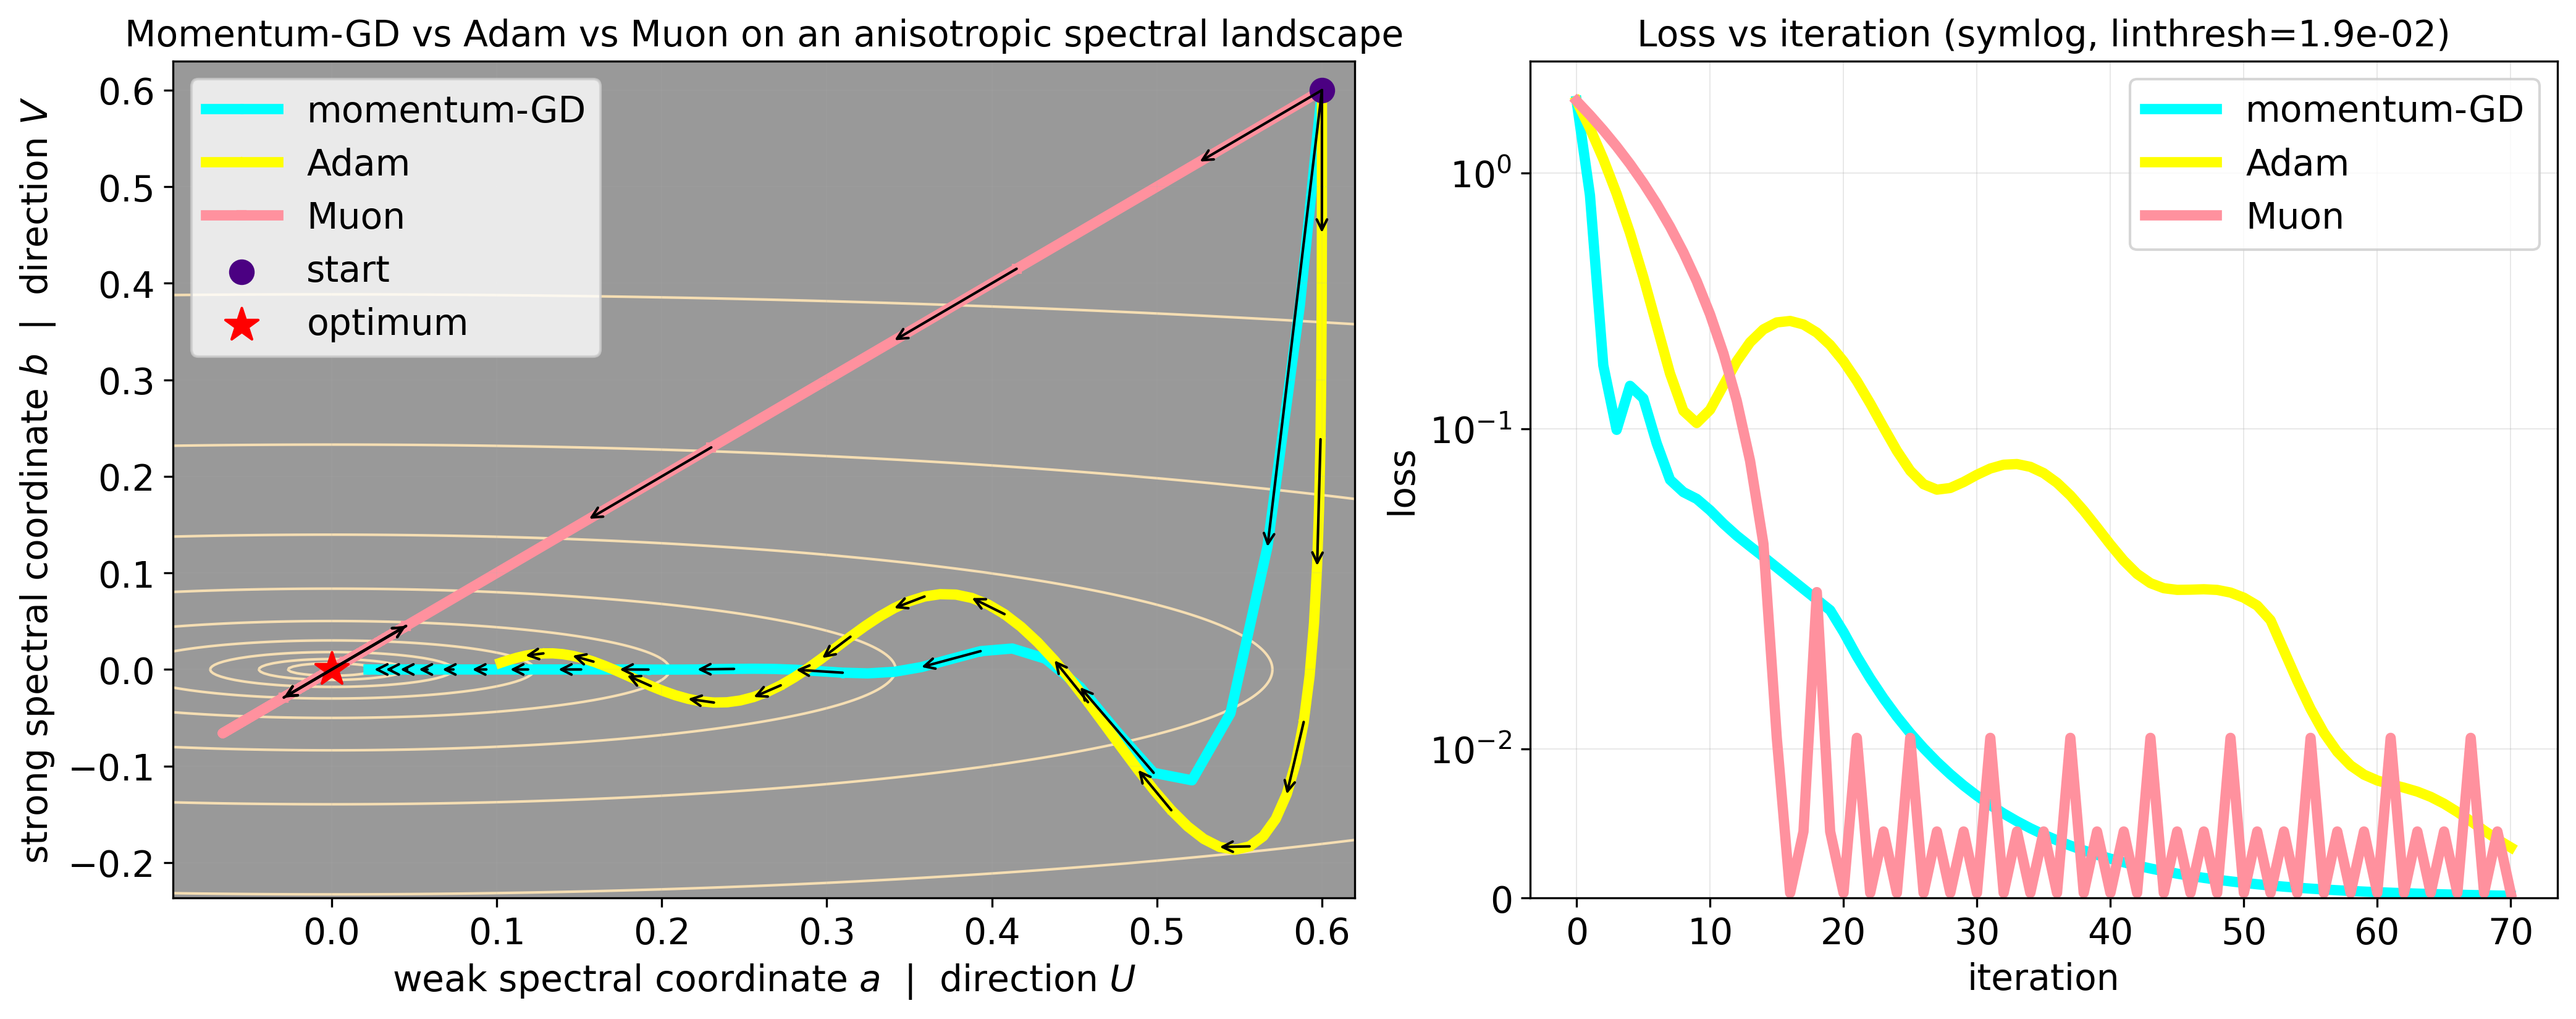

Saved figure to: two_dim_spectral_slice_case_pure.pdf


In [7]:
# Determine plotting range.
all_points = np.vstack([m_gd_path, adam_path, muon_path, np.array([[args.target_a, args.target_b]])])
a_min = min(np.min(all_points[:, 0]), args.start_a, args.target_a) - 0.03
a_max = max(np.max(all_points[:, 0]), args.start_a, args.target_a) + 0.02
b_min = min(np.min(all_points[:, 1]), args.start_b, args.target_b) - 0.05
b_max = max(np.max(all_points[:, 1]), args.start_b, args.target_b) + 0.03
a_grid = np.linspace(a_min, a_max, 500)
b_grid = np.linspace(b_min, b_max, 500)
# a_grid = np.linspace(-1.0, 0.7, 500)
# b_grid = np.linspace(-0.5, 0.7, 500)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)

Z = loss_value(A_grid, B_grid, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b,)
z_max = float(np.max(Z))
levels = np.geomspace(max(z_max * 1e-4, 1e-8), z_max, 10)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw=dict(width_ratios=[1.15, 1.0]))

cs = ax0.contour(A_grid, B_grid, Z, levels=levels, linewidths=1.0, colors="wheat", zorder=0)
#ax0.clabel(cs, inline=True, fontsize=10, fmt="%.2g")
line_m_gd, = ax0.plot(m_gd_path[:, 0], m_gd_path[:, 1],
                      marker="o", markersize=3, linewidth=4,
                      markevery=max(1, len(m_gd_path) // 12),
                      color="#00ffff", label="momentum-GD", zorder=1)
line_adam, = ax0.plot(adam_path[:, 0], adam_path[:, 1],
                      marker="p", markersize=3, linewidth=4,
                      markevery=max(1, len(adam_path) // 12),
                      color="#ffff00", label="Adam", zorder=1)
line_muon, = ax0.plot(muon_path[:, 0], muon_path[:, 1],
                      marker="s", markersize=3, linewidth=4,
                      markevery=max(1, len(muon_path) // 12),
                      color="#ff919e", label="Muon", zorder=1)
ax0.scatter([args.start_a], [args.start_b], marker="o", s=80, color="#4B0082", label="start", zorder=2)
ax0.scatter([args.target_a], [args.target_b], marker="*", s=180, color="red", label="optimum", zorder=2)
add_path_arrows(ax0, m_gd_path, every=max(2, len(m_gd_path) // 12))
add_path_arrows(ax0, adam_path, every=max(2, len(adam_path) // 12))
add_path_arrows(ax0, muon_path, every=max(2, len(muon_path) // 12))
ax0.set_xlabel(r"weak spectral coordinate $a$  |  direction $U$", fontsize=14)
ax0.set_ylabel(r"strong spectral coordinate $b$  |  direction $V$", fontsize=14)
ax0.set_facecolor("#999999")
ax0.grid(True, linewidth=0.4, alpha=0.15)
ax0.legend(loc="upper left", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(f"Momentum-GD vs Adam vs Muon on an anisotropic spectral landscape", fontsize=14)

ax1.plot(iters_m_gd, loss_m_gd, color="#00ffff", lw=4, label="momentum-GD")
ax1.plot(iters_adam, loss_adam, color="#ffff00", lw=4, label="Adam")
ax1.plot(iters_muon, loss_muon, color="#ff919e", lw=4, label="Muon")
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([loss_m_gd.max(), loss_adam.max(), loss_muon.max()])) * 1e-2)
ax1.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax1.set_ylim(bottom=0.0)
ax1.set_xlabel("iteration", fontsize=14)
ax1.set_ylabel("loss", fontsize=14)
#ax1.set_facecolor("#999999")
ax1.grid(True, linewidth=0.4, alpha=0.35)
ax1.legend(loc="upper right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(f"Loss vs iteration (symlog, linthresh={linthresh:.1e})", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("two_dim_spectral_slice_case_pure.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: two_dim_spectral_slice_case_pure.pdf")

### Run Optimization (“hybrid” setting)

In [8]:
path_muon_to_m_gd, path_muon_to_adam = simulate_hybrid(
    u=args.u,
    v=args.v,
    steps=args.steps,
    lam_weak=args.lambda_weak,
    lam_strong=args.lambda_strong,
    start_a=args.start_a,
    start_b=args.start_b,
    target_a=args.target_a,
    target_b=args.target_b,
    switch_muon_to_m_gd=args.switch_muon_to_m_gd,
    switch_muon_to_adam=args.switch_muon_to_adam,
    lr_muon=args.lr_muon,
    lr_m_gd=args.lr_m_gd,
    lr_adam=args.lr_adam,
    muon_momentum_xi=args.muon_momentum_xi,
    m_gd_momentum_xi=args.m_gd_momentum_xi,
    adam_beta1=args.adam_beta1,
    adam_beta2=args.adam_beta2,
    adam_eps=args.adam_eps,
    inherit_scale=args.inherit_scale,
)

loss_muon_to_m_gd = path_loss(path_muon_to_m_gd, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b)
loss_muon_to_adam = path_loss(path_muon_to_adam, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b)

iters_muon_to_m_gd = np.arange(len(loss_muon_to_m_gd))
iters_muon_to_adam = np.arange(len(loss_muon_to_adam))

print(f"final_a of Muon->momentum-GD: ", path_muon_to_m_gd[-1][0])
print(f"final_b of Muon->momentum-GD: ", path_muon_to_m_gd[-1][1])
print(f"final_loss of Muon->momentum-GD: ", loss_muon_to_m_gd[-1])
print(f"final_a of Muon->Adam: ", path_muon_to_adam[-1][0])
print(f"final_b of Muon->Adam: ", path_muon_to_adam[-1][1])
print(f"final_loss of Muon->Adam: ", loss_muon_to_adam[-1])

RMS of muonM_for_m_gd:  1.9326466454824347
RMS of muonM_for_adam:  1.9326466454824347
final_a of Muon->momentum-GD:  0.008243362456853486
final_b of Muon->momentum-GD:  1.4966842782487833e-10
final_loss of Muon->momentum-GD:  2.0385907378518577e-05
final_a of Muon->Adam:  0.003864763230154944
final_b of Muon->Adam:  -0.004308256114034428
final_loss of Muon->Adam:  9.728627216812243e-05


### Plot Results (“hybrid” setting)

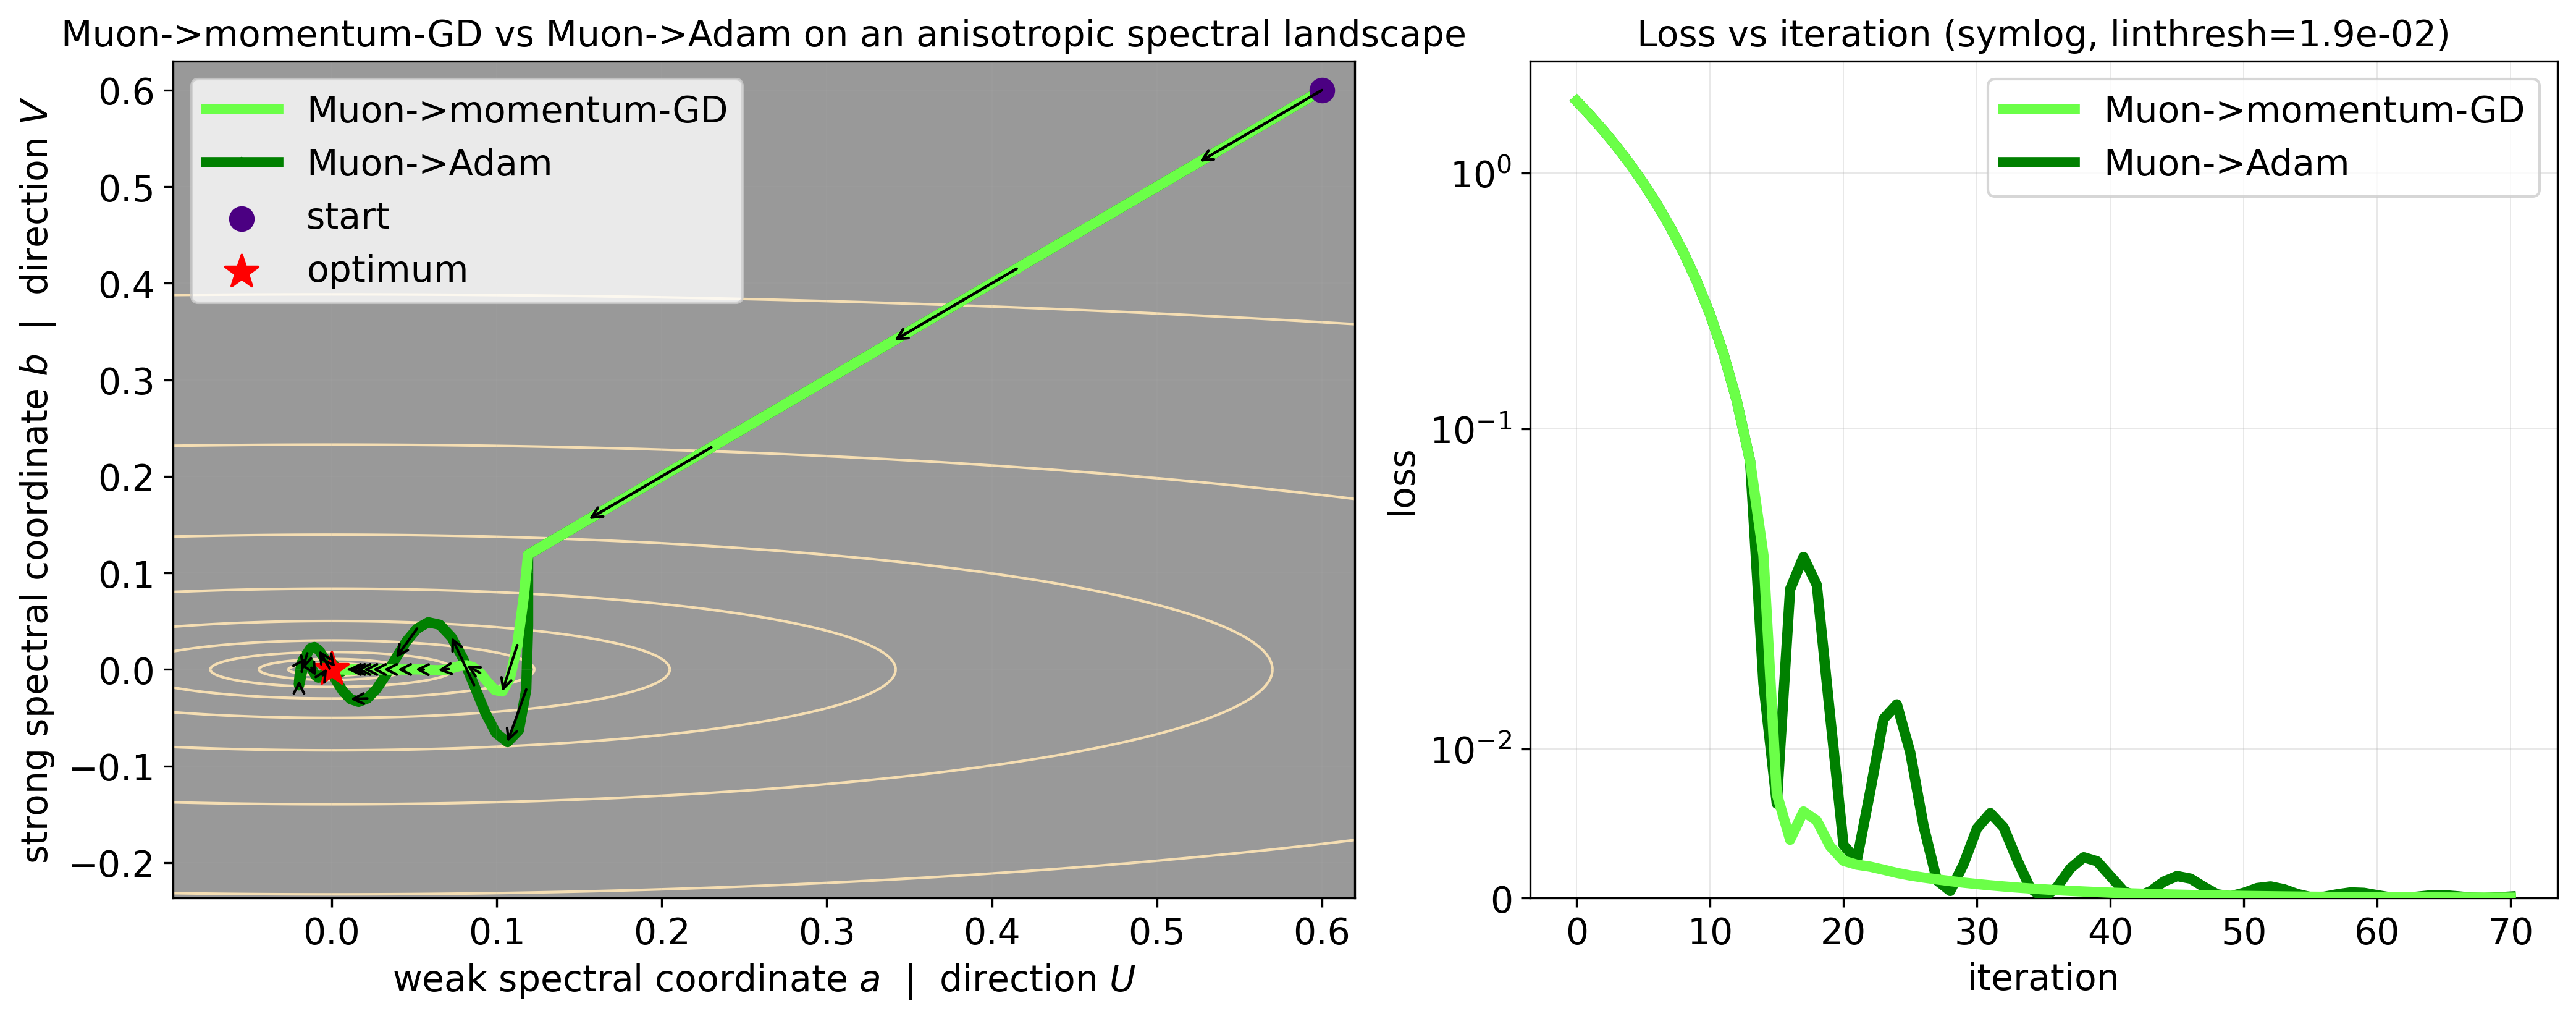

Saved figure to: two_dim_spectral_slice_case_hybrid.pdf


In [9]:
# Determine plotting range.
# all_points = np.vstack([path_muon_to_m_gd, path_muon_to_adam, np.array([[args.target_a, args.target_b]])])
# a_min = min(np.min(all_points[:, 0]), args.start_a, args.target_a) - 0.03
# a_max = max(np.max(all_points[:, 0]), args.start_a, args.target_a) + 0.02
# b_min = min(np.min(all_points[:, 1]), args.start_b, args.target_b) - 0.05
# b_max = max(np.max(all_points[:, 1]), args.start_b, args.target_b) + 0.03
a_grid = np.linspace(a_min, a_max, 500)
b_grid = np.linspace(b_min, b_max, 500)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)

Z = loss_value(A_grid, B_grid, args.lambda_weak, args.lambda_strong, args.target_a, args.target_b,)
z_max = float(np.max(Z))
levels = np.geomspace(max(z_max * 1e-4, 1e-8), z_max, 10)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw=dict(width_ratios=[1.15, 1.0]))

cs = ax0.contour(A_grid, B_grid, Z, levels=levels, linewidths=1.0, colors="wheat", zorder=0)
#ax0.clabel(cs, inline=True, fontsize=10, fmt="%.2g")
line_muon_to_m_gd, = ax0.plot(path_muon_to_m_gd[:, 0], path_muon_to_m_gd[:, 1],
                              marker="o", markersize=3, linewidth=4,
                              markevery=max(1, len(path_muon_to_m_gd) // 12),
                              color="#6bff48", label="Muon->momentum-GD", zorder=2)
line_muon_to_adam, = ax0.plot(path_muon_to_adam[:, 0], path_muon_to_adam[:, 1],
                              marker="p", markersize=3, linewidth=4,
                              markevery=max(1, len(path_muon_to_adam) // 12),
                              color="#008000", label="Muon->Adam", zorder=1)
ax0.scatter([args.start_a], [args.start_b], marker="o", s=80, color="#4B0082", label="start", zorder=3)
ax0.scatter([args.target_a], [args.target_b], marker="*", s=180, color="red", label="optimum", zorder=3)
add_path_arrows(ax0, path_muon_to_m_gd, every=max(2, len(path_muon_to_m_gd) // 12))
add_path_arrows(ax0, path_muon_to_adam, every=max(2, len(path_muon_to_adam) // 12))
ax0.set_xlabel(r"weak spectral coordinate $a$  |  direction $U$", fontsize=14)
ax0.set_ylabel(r"strong spectral coordinate $b$  |  direction $V$", fontsize=14)
ax0.set_facecolor("#999999")
ax0.grid(True, linewidth=0.4, alpha=0.15)
ax0.legend(loc="upper left", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(f"Muon->momentum-GD vs Muon->Adam on an anisotropic spectral landscape", fontsize=14)

ax1.plot(iters_muon_to_m_gd, loss_muon_to_m_gd, color="#6bff48", lw=4, label="Muon->momentum-GD", zorder=5)
ax1.plot(iters_muon_to_adam, loss_muon_to_adam, color="#008000", lw=4, label="Muon->Adam", zorder=4)
# linthresh：linear scale in [-linthresh, linthresh]
linthresh = max(1e-12, float(np.max([loss_muon_to_m_gd.max(), loss_muon_to_adam.max()])) * 1e-2)
ax1.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
ax1.set_ylim(bottom=0.0)
ax1.set_xlabel("iteration", fontsize=14)
ax1.set_ylabel("loss", fontsize=14)
#ax1.set_facecolor("#999999")
ax1.grid(True, linewidth=0.4, alpha=0.35)
ax1.legend(loc="upper right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(f"Loss vs iteration (symlog, linthresh={linthresh:.1e})", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("two_dim_spectral_slice_case_hybrid.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: two_dim_spectral_slice_case_hybrid.pdf")